# Classical Limit of the Quantum Ising Model

Number of spins along the 1D grid 25


Grid array:


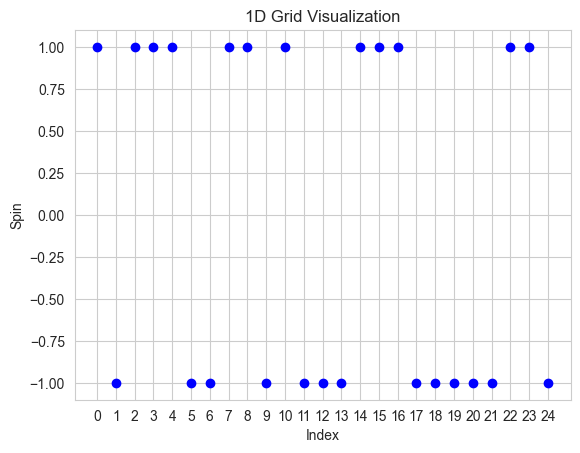

Desired temperature (K) for the grid environment: 1
Number of iterations for Metropolis-Hastings: 10000


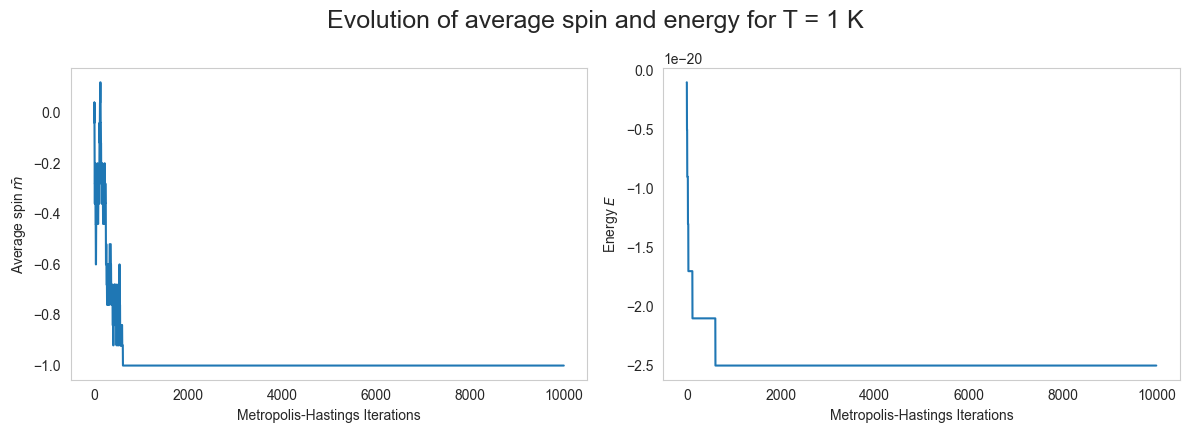

****************************************************************************************************
Now, calculation is performed to observe the algorithm behavior regarding multiple thermodynamic variables over a temperature range.


Minimum temperature (K): 1
Maximum temperature (K): 10000


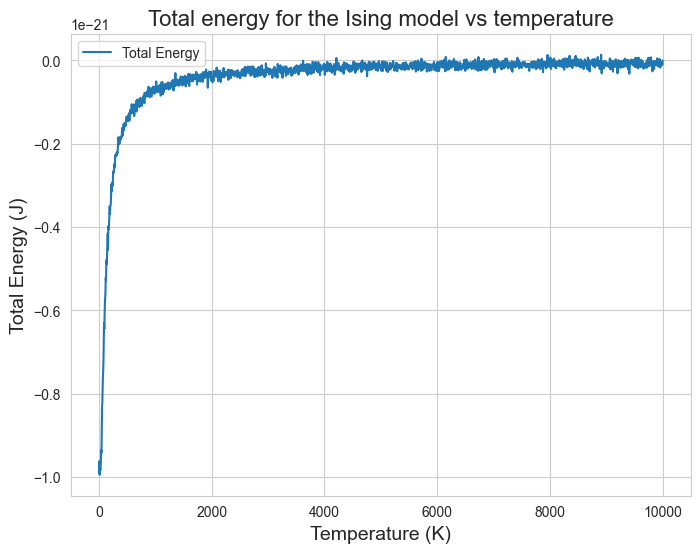

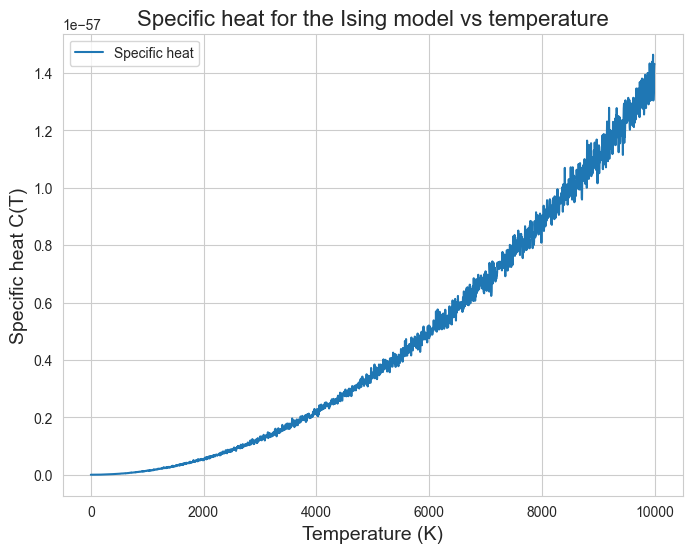

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import scipy.constants as sc
from scipy.ndimage import convolve
from scipy.ndimage import generate_binary_structure




'''
---------------------------------------------------------------
    
    Functions
    
---------------------------------------------------------------
'''

def visualize_1d_lattice(lattice):
    sns.set_style("whitegrid")
    plt.plot(lattice, marker='o', linestyle='None', color='blue')
    plt.title("1D Grid Visualization")
    plt.xlabel("Index")
    plt.ylabel("Spin")

    # Sets the ticks according to the lattice size
    x_ticks = np.arange(len(lattice))
    plt.xticks(x_ticks, labels=x_ticks)
    plt.show()
    

def generate_lattice():
    """
    Generates a lattice of random spins between -1 and +1, using uniform probability. It remains to be corroborated if a 50-50% probability is physically appropriate, since the average spin should be 0
    """
    lattice = None

    while True:
        try:
            size = int(input("Number of spins along the 1D grid"))
            break
        except ValueError:
            print("Wrong value, please use an integer")
    lattice = np.random.choice([-1, +1], size=size) #In case probability is different, add the last parameter

    return lattice



def lattice_energy(system, J):
    ''' 
    Performs a summation over each spin of the lattice in order to find its energy. The system is used, which is the array of spins with boundary conditions, the exchange energy J and no external magnetic field

    '''
    
    # In this case, which is one-dimensional, the nearest neighbors are simply the adjacent spins
    s_i_plus1 = np.roll(system,-1) #Shifts each s_i to the left, used due to the periodic boundary
    total_energy = -J*np.sum(system*s_i_plus1)
    return total_energy

 
def metropolis_1D_periodic(spin_array,times, T, J):
    '''
    Function that takes the one-dimensional array of spins with periodic conditions, the number of iterations times, the temperature T, the exchange energy J and no external magnetic field,
    and consequently performs MCMC to produce the array of net spins and energies

    '''
    energy = lattice_energy(spin_array,J)
    k = sc.Boltzmann
    B = 1/(k*T) # Beta in terms of temperature
    spin_array = spin_array.copy()
    net_spins = np.zeros(times-1)
    net_energy = np.zeros(times-1)
    for t in range(0,times-1):
        # 2. A random point in the array and a spin flip are chosen
        n_x = len(spin_array)
        x = np.random.randint(0,n_x)
        spin_i = spin_array[x] #Initial spin
        spin_f = spin_i*-1 #Proposed spin flip, since it only alternates between -1 and +1
        
        # Change of energy given the periodic boundary conditions
        E_i = 0
        E_f = 0
        # Left neighbor
        if x==0:
            E_i += -spin_i*spin_array[n_x-1]
            E_f += -spin_f*spin_array[n_x-1]
        if x>0:
            E_i += -spin_i*spin_array[x-1]
            E_f += -spin_f*spin_array[x-1]
        # Right neighbor
        if x<n_x-1:
            E_i += -spin_i*spin_array[x+1]
            E_f += -spin_f*spin_array[x+1]
        if x == n_x-1:
            E_i += -spin_i*spin_array[0]
            E_f += -spin_f*spin_array[0]
        
        # 3 / 4. State change for designated probabilities
        E_i = J*E_i
        E_f = J*E_f
        
        dE = E_f-E_i
        P = np.random.random(1)[0] # Generation of a random number
        if (dE>0)*(P < np.exp(-B*dE)):
            spin_array[x]=spin_f
            energy += dE
        elif dE<=0:
            spin_array[x]=spin_f
            energy += dE
            
        net_spins[t] = spin_array.sum()
        net_energy[t] = energy
            
    return net_spins, net_energy, spin_array



    
def thermo_calc_1D(min_temp, max_temp, system, times, J):
    ''' 
    Obtains the totals and deviations associated with energies and spins in the temperature range using MCMC and calculates the associated quantities.
    It works with the temperature limits, the system array representing the spin lattice, the exchange energy J and no magnetic field h
    '''
    k = sc.Boltzmann
    # Generation of an array for the specified temperature range
    temps = np.arange(min_temp, max_temp,5)
    n = len(temps)
    #Empty arrays for totals and variances
    E_totals = np.zeros(n)
    E_vars = np.zeros(n)
    C = np.zeros(n)
    N = len(system)
    
    # Iterates over all temperatures in the range, using Metropolis-Hastings to find spins and energies
    for i in range(n):
        spins, energies, lattice_final = metropolis_1D_periodic(system,times,temps[i],J) # MCMC for different temperatures
        
        E_totals[i] += np.mean(energies[-10000:])/(N) # Total energy at each temperature
        E_vars[i] += np.var(energies[-10000:]) # Energy variance for each temperature
        C[i] = E_vars[i]/(N)*k*(temps[i]**2) # Specific heat for energy variance

        
    return E_totals, C






"""

---------------------------------------------------------------

Main

----------------------------------------------------------------

"""


#Lattice generation
lattice = generate_lattice()
print("Grid array:")
visualize_1d_lattice(lattice)
n_x = lattice.shape[0]  #The lattice size is assigned according to the first dimension of n_x. In this case only n_x exists, but in order not to lose generality it is referred to like this instead of just as n
V = n_x





#System initialization
J = (1 * (10**-21)) # A low magnitude is chosen (corresponding to that of the Boltzmann constant) in order to avoid overflowing due to the magnitude of the energies.
#Also, J is chosen positive since it is chosen to study a ferromagnetic material


while True:
    T = input("Desired temperature (K) for the grid environment:")
    try: 
        T = int(T)
        break
    except:
        print ("Invalid, please write an integer.")

while True:
    iterations = input("Number of iterations for Metropolis-Hastings:")
    try: 
        iterations = int(iterations)
        break
    except:
        print ("Invalid, please write an integer.")
        
        
        
init_energy = lattice_energy(lattice,J)


#MCMC is applied to obtain the quantities

spins, energies, lattice_final =  metropolis_1D_periodic(lattice,iterations,T,J)  

 
#Plotting

fig,axes = plt.subplots(1,2,figsize=(12,4))
# Spin plot
ax = axes[0]
ax.plot(spins/V)
ax.set_xlabel("Metropolis-Hastings Iterations")
ax.set_ylabel(r'Average spin $\bar{m}$')
ax.grid()
# Plot for Energies
ax = axes[1]
ax.plot(energies)
ax.set_xlabel("Metropolis-Hastings Iterations")
ax.set_ylabel(r'Energy $E$')
ax.grid()
fig.tight_layout()
fig.suptitle(r'Evolution of average spin and energy for T = {} K'.format(T),y = 1.07, size=18)
plt.show()

#Obtaining the temperature range and thermodynamic data

print("*"*10**2)
print('Now, calculation is performed to observe the algorithm behavior regarding multiple thermodynamic variables over a temperature range.')
#Integers are used only for ease
while True:
    T_min = input("Minimum temperature (K):")
    try: 
        T_min = int(T_min)
        break
    except:
        print ("Invalid, please write an integer.")
while True:
    T_max = input("Maximum temperature (K):")
    try: 
        T_max = int(T_max)
        break
    except:
        print ("Invalid, please write an integer.")
        
temp_range = np.arange(T_min,T_max,5)        

E_totals, C = thermo_calc_1D(T_min, T_max, lattice, iterations, J)


#Plotting total energy vs temperature


# Seaborn is used
sns.set_style("whitegrid")

f1 = plt.figure(figsize=(8, 6)) 
plt.plot(temp_range, E_totals, label="Total Energy")
plt.title("Total energy for the Ising model vs temperature", fontsize=16)
plt.xlabel("Temperature (K)", fontsize=14)
plt.ylabel("Total Energy (J)", fontsize=14)
plt.legend()

plt.show()


#Specific heat vs temperature

sns.set_style("whitegrid")

f2 = plt.figure(figsize=(8, 6)) 
plt.plot(temp_range, C, label="Specific heat")
plt.title("Specific heat for the Ising model vs temperature", fontsize=16)
plt.xlabel("Temperature (K)", fontsize=14)
plt.ylabel("Specific heat C(T)", fontsize=14)
plt.legend()

plt.show()

# Transversal Ising Model

Transverse Ising Model
Monte Carlo Simulation
Sweep of h: 0.1 -> 2.0)
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 0.1


Point 1/20: h = 0.10 -> |mz| = 0.9986
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 0.2


Point 2/20: h = 0.20 -> |mz| = 0.9940
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 0.3


Point 3/20: h = 0.30 -> |mz| = 0.9908
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 0.4


Point 4/20: h = 0.40 -> |mz| = 0.9800
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 0.5


...

Point 16/20: h = 1.60 -> |mz| = 0.2615
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 1.7


Point 17/20: h = 1.70 -> |mz| = 0.2212
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 1.8


Point 18/20: h = 1.80 -> |mz| = 0.1917
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 1.9


Point 19/20: h = 1.90 -> |mz| = 0.1978
PIMC: 8 spins, 80 Trotter slices, β = 8.0
Parameters: J = 1.0, h = 2.0


Point 20/20: h = 2.00 -> |mz| = 0.1941


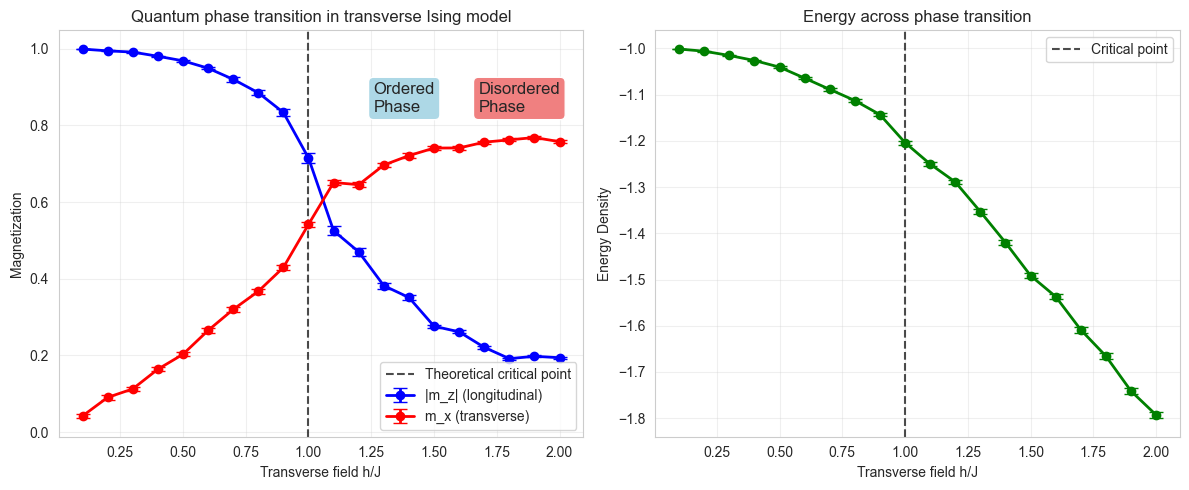


Comparison with analytical results (Exact Diagonalization)
h/J = 0.5: |m_z| = 0.9693, m_x = 0.2601, E_density = -1.0636
h/J = 1.0: |m_z| = 0.7858, m_x = 0.6407, E_density = -1.2815
h/J = 1.5: |m_z| = 0.5615, m_x = 0.8723, E_density = -1.6731


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

class TransverseIsingPIMC:
    """
    
    Path Integral Monte Carlo (PIMC) for the Ising model with a transverse external field. 
    Since the process is more complex than the previous one (classical model), it is more convenient to generate a class with the process variables and functions.
    """
    
    def __init__(self, N, J=1.0, h=1.0, beta=1.0, M=20):
        """
        PIMC simulation is initialized
        """
        self.N = N
        self.J = J
        self.h = h
        self.beta = beta
        self.M = M
        
        # Imaginary time discretization
        self.dtau = beta / M
        
        # Spin configuration initialization, with N spatial positions x M temporal slices
        self.config = np.random.choice([-1, 1], size=(N, M))
        
        # Coupling constant for the imaginary time direction is computed beforehand
        self.K = -0.5 * np.log(np.tanh(self.dtau * self.h))
        # IMPORTANT, since the temporal constant depends on the field, evaluating the case approximately without external field will cause this value to tend to infinity due to the logarithm
        
    def magnetization_z_sq(self, config):
        """
        Calculation of longitudinal magnetization density. The mean square is calculated, then the square root will be taken outside this function
        """
        m_z = np.mean(config)
        return m_z ** 2 # Return the square of the instantaneous average
    
    def magnetization_x(self, config):
        """
        A convenient way to perform this calculation is by counting the "kinks", or 
        the flips in imaginary time.
        """
        # 1. Identify where spins occur between t and t+1
        # If configuration equals configuration after np.roll, product is 1.
        # Otherwise, it is -1

        time_correlations = config * np.roll(config, -1, axis=1) 
        
        # -1 implies presence of a kink; 1, absence of a kink
        # So, count how many cells have kinks
        num_kinks = np.sum(time_correlations == -1)
        
        # Estimator formula for kink density, which gives mx
        mx = num_kinks / (self.N * self.beta * self.h)
        
        return mx

    def energy_density(self, config):
        """
        Calculates interaction energy and transverse field energy
        E_total = <H_z> + <H_x>
        """
        # H_z: Interaction Energy
        # E_z = -J * <sum(S_i * S_i+1)> , same as performed previously in classical calculation
        spatial_correlations = config * np.roll(config, -1, axis=0)
        E_z = -self.J * np.mean(spatial_correlations)
        
        # H_x: Transverse Field Energy
        # E_x = -h * <m_x>
        # Same calculation performed in magnetization function, but calculated locally to be contained within this specific calculation
        time_correlations = config * np.roll(config, -1, axis=1) 
        num_kinks = np.sum(time_correlations == -1)
        m_x_val = num_kinks / (self.N * self.beta * self.h)
        
        E_x = -self.h * m_x_val
        
        return E_z + E_x
        
    
    

    def local_update(self, config, i, t):
        """
        Metropolis update is performed for a spin at position (i, t)
        This process could be performed with Gibbs sampling, but would require conditional probability, 
        which would need implementation of alternate methods like using RBMs
        """
        current_spin = config[i, t]
        
        # Calculation of energy change for acceptance criterion
        delta_E = 0.0
        
        # Spatial neighbors within the same time slice
        left = config[(i-1) % self.N, t]
        right = config[(i+1) % self.N, t]
        
        # Now, for the spatial part it is necessary to multiply by dTau
        delta_E += 2 * (self.dtau * self.J) * current_spin * (left + right)
        
        # Temporal neighbors, analogous to previous case, but fixing site and varying time
        t_prev = (t - 1) % self.M
        t_next = (t + 1) % self.M
        # delta E also integrates the term associated with this imaginary time, and here the temporal coupling constant is used
        delta_E += 2 * self.K * current_spin * (config[i, t_prev] + config[i, t_next]) 
        
        # The standard acceptance criterion
        if delta_E <= 0 or np.random.random() < np.exp(-delta_E):
            config[i, t] = -current_spin
            return True
        return False
        
    def wolff_update(self, config):
        """
        Cluster algorithm (Wolff) for more efficient calculations.
        Cluster update (Wolff algorithm) for more efficient sampling
        """
        # A random "seed" for the spin is chosen
        i0, t0 = np.random.randint(0, self.N), np.random.randint(0, self.M)
        cluster = [(i0, t0)]
        stack = [(i0, t0)]
        old_spin = config[i0, t0]
        
        # Cluster is built
        while stack:
            i, t = stack.pop()
            
            # Check for spatial neighbors
            for di in [-1, 1]:
                i_nbr = (i + di) % self.N
                if (i_nbr, t) not in cluster:
                    # Original probability: 1 - exp(-2 * J * dtau). 
                    # This is the classical coupling for the spatial term
                    # The spatial coupling for the classical case is then J_cl = dtau*J.
                    # Explicit probability is used for classical case K, K_tau:
                    P_add = (1 - np.exp(-2 * self.dtau * self.J)) # P_add for spatial
                    if (config[i_nbr, t] == old_spin and 
                        np.random.random() < P_add):
                        cluster.append((i_nbr, t))
                        stack.append((i_nbr, t))
                        
            # Now procedure is repeated for temporal neighbors
            for dt in [-1, 1]:
                t_nbr = (t + dt) % self.M
                if (i, t_nbr) not in cluster:
                    # Original probability: 1 - exp(-2 * K)
                    P_add_tau = (1 - np.exp(-2 * self.K)) # P_add for temporal term
                    if (config[i, t_nbr] == old_spin and 
                        np.random.random() < P_add_tau):
                        cluster.append((i, t_nbr))
                        stack.append((i, t_nbr))
        
        # A flip is performed over the entire cluster
        for i, t in cluster:
            config[i, t] = -config[i, t]
        
        return len(cluster)
        
    def run(self, n_sweeps, thermalization=0.2, measure_every=10):
        """
        Complete Monte Carlo Simulation
        """
        print(f"PIMC: {self.N} spins, {self.M} Trotter slices, β = {self.beta}")
        print(f"Parameters: J = {self.J}, h = {self.h}")
        n_therm = int(n_sweeps * thermalization)
        
        
        # Arrays to save measurements
        energies = []
        mag_z_sq_values = [] 
        mag_x_values = []

        # A progress bar is used
        iterator = tqdm(range(n_sweeps), desc=f"Simulating h={self.h:.2f}", leave=False, ncols=80)
        

        
        for sweep in iterator:
            # A mixed update is performed, local + cluster (the latter occasionally, not every time)
            if sweep % 10 == 0:  # Cluster update every 10 sweeps
                self.wolff_update(self.config)
            else:  # local updates
                for _ in range(self.N * self.M):
                    i = np.random.randint(0, self.N)
                    t = np.random.randint(0, self.M)
                    self.local_update(self.config, i, t)
            
            # Measurement of observables after thermalization
            if sweep >= n_therm and sweep % measure_every == 0:
                energy = self.energy_density(self.config)
                mag_z_sq = self.magnetization_z_sq(self.config)
                mag_x = self.magnetization_x(self.config)
                
                energies.append(energy)
                mag_z_sq_values.append(mag_z_sq)
                mag_x_values.append(mag_x)
        
        # Average values and errors
        
        # As mentioned in magnetization function, now root is taken to obtain |mz|
        mean_mz_sq = np.mean(mag_z_sq_values)
        final_mz = np.sqrt(mean_mz_sq)
        
        # mz deviation is used to quantify error propagation
        mz_sq_std = np.std(mag_z_sq_values) / np.sqrt(len(mag_z_sq_values))
        # This is merely an approximation, but for illustrative terms it manages to visualize how error works according to parameters

        results = {
            'energy': np.mean(energies),
            'energy_std': np.std(energies) / np.sqrt(len(energies)),
            'magnetization_z': final_mz, 
            'magnetization_z_std': mz_sq_std,
            'magnetization_x': np.mean(mag_x_values),
            'magnetization_x_std': np.std(mag_x_values) / np.sqrt(len(mag_x_values)),
        }
        
        return results

def quick_critical_check(n_points=20, h_min=0.1, h_max=2.0):
    """
    Verification using a linspace to sweep field h.
    Generates n_points between h_min and h_max and obtains calculations with which it will later be verified
    """
    
    print(f"Sweep of h: {h_min} -> {h_max})")
    print("=" * 60)
    
    h_values = np.linspace(h_min, h_max, n_points)
    
    all_results = []
    
    # Fixed parameters for the test, want to see change regarding h
    base_params = {'N': 8, 'J': 1.0, 'beta': 8.0, 'M': 80}
    
    for i, h in enumerate(h_values):
        # Update h
        params = base_params.copy()
        params['h'] = h
        
        # Run model with parameters
        model = TransverseIsingPIMC(**params)
        results = model.run(n_sweeps=2500, thermalization=0.2, measure_every=5)
        
        # Save results
        results['h'] = h
        
        # Dynamic label, to observe behavior in ranges of greatest interest
        if h < 0.9:
            results['label'] = 'Ordered'
        elif h > 1.1:
            results['label'] = 'Disordered'
        else:
            results['label'] = 'Critical'
            
        all_results.append(results)
        
        # Simple text progress bar
        print(f"Point {i+1}/{n_points}: h = {h:.2f} -> |mz| = {results['magnetization_z']:.4f}")
    
    return all_results

def plot_quick_results(results):
    """Plot the quick verification results"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Data extraction
    h_vals = [r['h'] for r in results]
    mz_vals = [r['magnetization_z'] for r in results]
    mz_err = [r['magnetization_z_std'] for r in results]
    mx_vals = [r['magnetization_x'] for r in results]
    mx_err = [r['magnetization_x_std'] for r in results]
    
    # Magnetization plotting
    ax1.errorbar(h_vals, mz_vals, yerr=mz_err, fmt='bo-', label='|m_z| (longitudinal)', capsize=5, linewidth=2)
    ax1.errorbar(h_vals, mx_vals, yerr=mx_err, fmt='ro-', label='m_x (transverse)', capsize=5, linewidth=2)
    ax1.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, label='Theoretical critical point')
    ax1.set_xlabel('Transverse field h/J')
    ax1.set_ylabel('Magnetization')
    ax1.set_title('Quantum phase transition in transverse Ising model')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Phase labels
    ax1.text(0.6, 0.8, 'Ordered\nPhase', transform=ax1.transAxes, fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    ax1.text(0.8, 0.8, 'Disordered\nPhase', transform=ax1.transAxes, fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
    
    # Energy plotting
    energy_vals = [r['energy'] for r in results]
    energy_err = [r['energy_std'] for r in results]
    
    ax2.errorbar(h_vals, energy_vals, yerr=energy_err, fmt='go-', capsize=5, linewidth=2)
    ax2.axvline(x=1.0, color='black', linestyle='--', alpha=0.7, label='Critical point')
    ax2.set_xlabel('Transverse field h/J')
    ax2.set_ylabel('Energy Density')
    ax2.set_title('Energy across phase transition')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

def analytical_benchmark():
    """Compare with exact diagonalization results"""
    print("\n" + "=" * 60)
    print("Comparison with analytical results (Exact Diagonalization)")
    print("=" * 60)
    
    def get_pauli(n, size, pauli_type):
        if pauli_type not in ['x', 'y', 'z']:
            raise ValueError("pauli_type must be 'x', 'y', or 'z'")
        pauli_matrices = {
            'x': np.array([[0, 1], [1, 0]], dtype=complex),
            'y': np.array([[0, -1j], [1j, 0]], dtype=complex),
            'z': np.array([[1, 0], [0, -1]], dtype=complex)
        }
        op = pauli_matrices[pauli_type]
        full_op = 1
        for i in range(size):
            if i == n:
                full_op = np.kron(full_op, op)
            else:
                full_op = np.kron(full_op, np.eye(2))
        return full_op

    def build_tfim_hamiltonian(N, J=1.0, h=1.0):
        H = sp.csr_matrix((2**N, 2**N), dtype=complex)
        # Interaction term
        for i in range(N):
            j = (i + 1) % N
            sz_i = get_pauli(i, N, 'z')
            sz_j = get_pauli(j, N, 'z')
            H -= J * (sz_i @ sz_j)
        # Transverse field term
        for i in range(N):
            sx_i = get_pauli(i, N, 'x')
            H -= h * sx_i
        return H.real

    N = 8  # Small system chosen for convenience
    test_h = [0.5, 1.0, 1.5] # These are 3 values in the three points of interest: ordered regime, critical regime and disordered regime
    
    for h in test_h:
        H = build_tfim_hamiltonian(N, J=1.0, h=h)
        eigenvalues, eigenvectors = eigsh(H, k=1, which='SA')
        ground_state = eigenvectors[:, 0]
        
        # 1. Calculation of operator Mz (sum of sigma_z)
        Mz_op = sp.csr_matrix((2**N, 2**N), dtype=complex)
        Mx_op = sp.csr_matrix((2**N, 2**N), dtype=complex)
        
        for i in range(N):
            Mz_op += get_pauli(i, N, 'z')
            Mx_op += get_pauli(i, N, 'x')
            
        # 2. Calculation of expectation value of Mz^2, squared magnetization
        mz_sq_exp = (ground_state.conj().T @ (Mz_op @ Mz_op) @ ground_state).real.item()
        # @ is matrix multiplication operator
        
        # 3. Calculation of RMS magnetization per site:
        m_z = np.sqrt(mz_sq_exp) / N
        
        # 4. Calculation of transverse magnetization per site
        m_x = (ground_state.conj().T @ Mx_op @ ground_state).real.item() / N
        
        # 5. Calculation of energy density
        e_density = eigenvalues[0].real / N
        
        print(f"h/J = {h:.1f}: |m_z| = {m_z:.4f}, m_x = {m_x:.4f}, E_density = {e_density:.4f}")

if __name__ == "__main__":
    print("Transverse Ising Model")
    print("Monte Carlo Simulation")
    print("=" * 60)
    
    results = quick_critical_check()
    
    plot_quick_results(results)
    
    analytical_benchmark()

# Dissipative Transverse Field Ising

Notar como, en el caso sin disipación, se llega a los mismos resultados vistos para la aproximación del modelo de Ising transversal regular

## Plotting of magnetization with respect to dissipation

 DISSIPATIVE PHASE DIAGRAM GENERATION
Fixed parameters: N=8, h=1.5, beta=10.0
Scanning Alpha: [0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6, 2.0]
------------------------------------------------------------


Alpha sweep:  10%|███                            | 1/10 [00:24<03:39, 24.41s/it]

α = 0.00: |m_z| = 0.2402, m_x = 0.6629 (24.4s)


Alpha sweep:  20%|██████▏                        | 2/10 [01:02<04:17, 32.16s/it]

α = 0.02: |m_z| = 0.3509, m_x = 0.5926 (37.6s)


...

α = 1.20: |m_z| = 1.0000, m_x = 0.0001 (32.0s)


Alpha sweep:  90%|███████████████████████████▉   | 9/10 [05:17<00:34, 34.07s/it]

α = 1.60: |m_z| = 1.0000, m_x = 0.0000 (31.0s)


Alpha sweep: 100%|██████████████████████████████| 10/10 [05:46<00:00, 34.65s/it]

α = 2.00: |m_z| = 1.0000, m_x = 0.0000 (28.5s)
------------------------------------------------------------
Total time: 346.5s


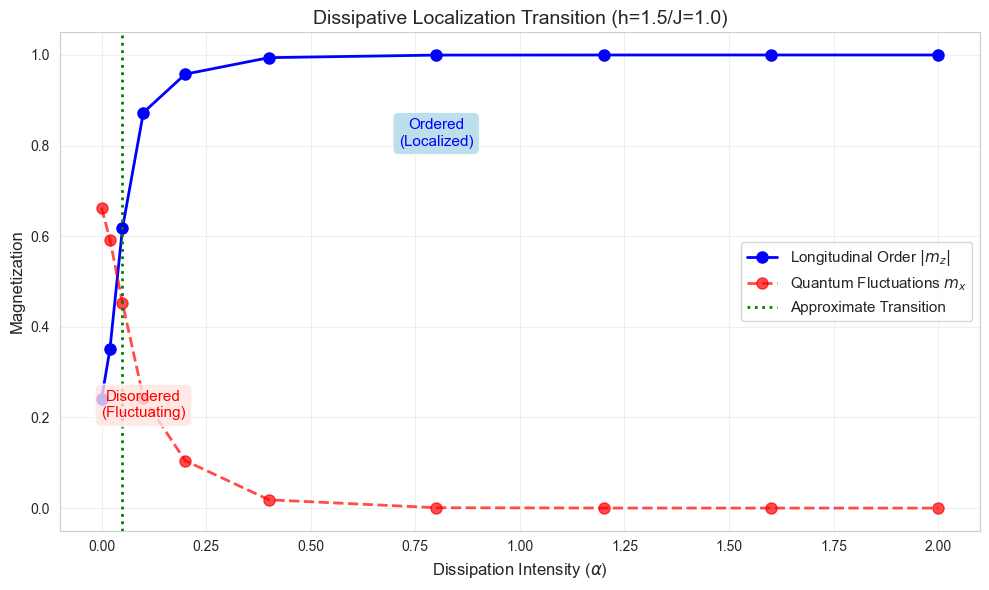


INTERPRETATION:
------------------------------------------------------------
• α = 0: Quantum disordered phase (low |m_z|, high m_x)
• α ≈ 0.05: Critical transition point
• α > 0.2: Localized phase (high |m_z|, low m_x)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

class DissipativePIMC:
    """
    Path Integral Monte Carlo (PIMC) for the dissipative transverse field Ising model.
    Global updates are included to prevent freezing at high dissipation.
    """
    
    def __init__(self, N, J=1.0, h=1.0, beta=1.0, M=60, alpha=0.0):
        """
        Initialization of PIMC simulation with dissipation.
        
        M is set to 60 by default for faster plotting speed.
        Increase to 80 or 100 for publication-quality data.
        """
        self.N = N
        self.J = J
        self.h = h
        self.beta = beta
        self.M = M
        self.alpha = alpha
        
        # Imaginary time discretization
        self.dtau = beta / M
        
        # Spin configuration initialization
        self.config = np.random.choice([-1, 1], size=(N, M))
        
        # Temporal coupling constant
        self.K = -0.5 * np.log(np.tanh(self.dtau * self.h))
        
        # Dissipative kernel matrix
        self.kernel_matrix = np.zeros((M, M))
        if self.alpha > 0:
            self._precompute_kernel()
            
    def _precompute_kernel(self):
        """
        Pre-calculation of the dissipative kernel.
        Dissipation introduces non-local interactions in imaginary time.
        """
        for t in range(self.M):
            for t_prime in range(self.M):
                if t == t_prime: 
                    continue
                
                # Distance between time slices
                dist_slices = abs(t - t_prime)
                
                # Chord distance metric
                chord_dist_sq = (self.M / np.pi * np.sin(np.pi * dist_slices / self.M))**2
                
                # Dissipative coupling
                coupling = self.alpha * (np.pi**2) / (self.M**2) / (np.sin(np.pi * dist_slices / self.M)**2)
                
                self.kernel_matrix[t, t_prime] = coupling

    def measure_observables(self):
        """
        Measurement of system observables:
        1. Longitudinal magnetization |m_z|
        2. Transverse magnetization m_x (kink counting)
        """
        # 1. Longitudinal magnetization
        m_z = np.mean(self.config)
        m_z_sq = m_z**2
        
        # 2. Transverse magnetization (kink counting)
        time_correlations = self.config * np.roll(self.config, -1, axis=1)
        num_kinks = np.sum(time_correlations == -1)
        m_x = num_kinks / (self.N * self.beta * self.h)
        
        return m_z_sq, m_x

    def local_update(self, i, t):
        """
        Standard single-site local update (i, t).
        Includes spatial, temporal, and dissipative terms.
        """
        current_spin = self.config[i, t]
        
        # Spatial term: neighbors in the same time slice
        left = self.config[(i-1) % self.N, t]
        right = self.config[(i+1) % self.N, t]
        delta_E_spatial = 2 * (self.dtau * self.J) * current_spin * (left + right)
        
        # Temporal term: neighbors in adjacent slices
        t_prev = (t - 1) % self.M
        t_next = (t + 1) % self.M
        delta_E_temporal = 2 * self.K * current_spin * (self.config[i, t_prev] + self.config[i, t_next])
        
        # Dissipative term: non-local interaction in imaginary time
        delta_E_diss = 0.0
        if self.alpha > 0:
            interaction_sum = np.dot(self.kernel_matrix[t, :], self.config[i, :])
            delta_E_diss = 2 * current_spin * interaction_sum

        # Total energy change
        delta_E = delta_E_spatial + delta_E_temporal + delta_E_diss
        
        # Metropolis acceptance criterion
        if delta_E <= 0 or np.random.random() < np.exp(-delta_E):
            self.config[i, t] = -current_spin

    def uniform_update(self, i):
        """
        GLOBAL UPDATE: flips the entire temporal rod at spatial site i.
        Crucial for high alpha, prevents system freezing.
        """
        current_rod = self.config[i, :]
        left_rod = self.config[(i-1) % self.N, :]
        right_rod = self.config[(i+1) % self.N, :]
        
        # Calculation of spatial energy change for the entire rod
        spatial_neighbors = left_rod + right_rod
        delta_E_total = 2 * (self.dtau * self.J) * np.sum(current_rod * spatial_neighbors)
        
        # Acceptance criterion for the entire rod
        if delta_E_total <= 0 or np.random.random() < np.exp(-delta_E_total):
            self.config[i, :] *= -1 

    def run(self, n_sweeps, thermalization=0.3):
        """
        Complete Monte Carlo simulation with dissipation.
        Combines local updates with global updates.
        """
        n_therm = int(n_sweeps * thermalization)
        
        # Arrays to save measurements
        mz_sq_list = []
        mx_list = []
        
        for sweep in range(n_sweeps):
            # 1. Local updates
            for _ in range(self.N * self.M):
                i = np.random.randint(0, self.N)
                t = np.random.randint(0, self.M)
                self.local_update(i, t)
            
            # 2. Uniform updates
            for i in range(self.N):
                self.uniform_update(i)
            
            # Measurements after thermalization
            if sweep >= n_therm and sweep % 10 == 0:
                mz_sq, mx = self.measure_observables()
                mz_sq_list.append(mz_sq)
                mx_list.append(mx)
        
        # Average calculation
        final_mz = np.sqrt(np.mean(mz_sq_list))
        final_mx = np.mean(mx_list)
        
        return {'m_z': final_mz, 'm_x': final_mx}

# ==========================================
# PHASE TRANSITION PLOTTING SCRIPT
# ==========================================
if __name__ == "__main__":
    print("=" * 60)
    print(" DISSIPATIVE PHASE DIAGRAM GENERATION")
    print("=" * 60)
    
    # 1. Parameter definition
    # h=1.5 is chosen because it is in the disordered phase (low m_z) when alpha=0.
    # It is desired to observe how it becomes ordered (high m_z) as alpha increases.
    N = 8
    J = 1.0
    h = 1.5 
    beta = 10.0
    M = 60  # Time slices
    sweeps = 3000  # Sweeps per point
    
    # Range of Alpha values to scan
    # Concentrated around 0.05 where the transition likely occurs
    alpha_values = [0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6, 2.0]
    
    mz_results = []
    mx_results = []
    
    print(f"Fixed parameters: N={N}, h={h}, beta={beta}")
    print(f"Scanning Alpha: {alpha_values}")
    print("-" * 60)
    
    start_total = time.time()
    
    # 2. Loop execution
    # Tqdm is used to show sweep progress
    for alpha in tqdm(alpha_values, desc="Alpha sweep", ncols=80):
        t0 = time.time()
        
        sim = DissipativePIMC(N, J, h, beta, M, alpha)
        res = sim.run(n_sweeps=sweeps)
        
        mz_results.append(res['m_z'])
        mx_results.append(res['m_x'])
        
        dt = time.time() - t0
        print(f"α = {alpha:.2f}: |m_z| = {res['m_z']:.4f}, m_x = {res['m_x']:.4f} ({dt:.1f}s)")

    print("-" * 60)
    print(f"Total time: {(time.time() - start_total):.1f}s")

    # 3. Plotting results
    plt.figure(figsize=(10, 6))
    
    # Plotting order parameter (m_z)
    plt.plot(alpha_values, mz_results, 'bo-', linewidth=2, markersize=8, 
             label='Longitudinal Order $|m_z|$')
    
    # Plotting quantum fluctuations (m_x)
    plt.plot(alpha_values, mx_results, 'ro--', linewidth=2, markersize=8, 
             alpha=0.7, label='Quantum Fluctuations $m_x$')
    
    # Aesthetics
    plt.title(f'Dissipative Localization Transition (h={h}/J={J})', fontsize=14)
    plt.xlabel(r'Dissipation Intensity ($\alpha$)', fontsize=12)
    plt.ylabel('Magnetization', fontsize=12)
    plt.axvline(x=0.05, color='green', linestyle=':', linewidth=2, 
                label='Approximate Transition')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    
    # Phase annotations
    plt.text(0.1, 0.2, 'Disordered\n(Fluctuating)', color='red', 
             ha='center', fontsize=11, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="mistyrose", alpha=0.8))
    plt.text(0.8, 0.8, 'Ordered\n(Localized)', color='blue', 
             ha='center', fontsize=11,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="lightblue", alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)
    print("INTERPRETATION:")
    print("-" * 60)
    print("• α = 0: Quantum disordered phase (low |m_z|, high m_x)")
    print("• α ≈ 0.05: Critical transition point")
    print("• α > 0.2: Localized phase (high |m_z|, low m_x)")
    print("=" * 60)